In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
import cv2
import os
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
csv_filepath = "/content/drive/MyDrive/data"

In [4]:
filepath = "/content/drive/MyDrive/required_images"

In [5]:
train_df = pd.read_csv(os.path.join(csv_filepath,'train_df.csv'))
val_df = pd.read_csv(os.path.join(csv_filepath,'val_df.csv'))
test_df = pd.read_csv(os.path.join(csv_filepath,'test_df.csv'))

In [6]:
def train_transform_pipeline(filepath):
    transform = transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomResizedCrop(size=224, scale=(0.9, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = Image.fromarray(img)
    img = transform(img)
    return img

In [7]:
def transform_pipeline(filepath):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = transform(img)
    return img

In [8]:
import torch

In [9]:
class ChestXrayDataset(torch.utils.data.Dataset):
      def __init__(self,df,filepath,transform_fn):
         self.df = df.reset_index(drop=True)
         self.filepath = filepath
         self.transform_fn = transform_fn

      def __len__(self):
         return len(self.df)

      def __getitem__(self, index):
          img_path = os.path.join(self.filepath,self.df.loc[index,'filename'])
          img = self.transform_fn(img_path)
          label = self.df.loc[index,'label']
          return img, label

In [10]:
train_dataset = ChestXrayDataset(train_df,filepath,train_transform_pipeline)
val_dataset = ChestXrayDataset(val_df,filepath,transform_pipeline)
test_dataset = ChestXrayDataset(test_df,filepath,transform_pipeline)

In [11]:
from torch.utils.data import DataLoader

In [12]:
train_loader = DataLoader(dataset = train_dataset,batch_size=16,shuffle=True,num_workers=2)
val_loader = DataLoader(dataset = val_dataset,batch_size=16,shuffle=False,num_workers=2)
test_loader = DataLoader(dataset = test_dataset,batch_size=16,shuffle=False,num_workers=2)

In [13]:
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights = ResNet18_Weights.DEFAULT)

In [14]:
for param in model.parameters():
    param.requires_grad = False

In [15]:
import torch.nn as nn

In [16]:
model.fc = nn.Linear(model.fc.in_features,2)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
weight = torch.tensor([1/0.365174,1/0.634826])
weight = weight / weight.sum()
criterion = nn.CrossEntropyLoss(weight = weight.to(device))

In [19]:
import torch.optim as optim

In [20]:
optimizer = optim.Adam(model.parameters(),lr = 0.001)

In [21]:
model = model.to(device)

In [22]:
import os

folder = '/content/drive/MyDrive/models'

for filename in os.listdir(folder):
    file_path = os.path.join(folder,filename)

    if os.path.isfile(file_path):
       os.remove(file_path)

In [24]:
for epoch in range(10):
    loss_train_list = list()
    loss_val_list = list()
    model.train()
    for batch_idx , (image , label) in enumerate(train_loader):
        optimizer.zero_grad()
        image = image.to(device)
        outputs = model(image)
        label = label.to(device)
        loss_train = criterion(outputs,label)
        loss_train.backward()
        loss_train_list.append(loss_train.item())
        optimizer.step()
    torch.save(model.state_dict(),f"/content/drive/MyDrive/models/epoch_{epoch + 1}.pt")
    model.eval()
    for batch_idx , (image , label) in enumerate(val_loader):
        with torch.no_grad():
             image = image.to(device)
             outputs = model(image)
             label = label.to(device)
             loss_val = criterion(outputs,label)
             loss_val_list.append(loss_val.item())
    mean_train = sum(loss_train_list)/len(loss_train_list)
    mean_val = sum(loss_val_list)/len(loss_val_list)
    print(f"Epoch : {epoch + 1}, Train Loss : {mean_train:.4f}, Val Loss : {mean_val:.4f}")

Epoch : 1, Train Loss : 0.6476, Val Loss : 0.6586
Epoch : 2, Train Loss : 0.6479, Val Loss : 0.6249
Epoch : 3, Train Loss : 0.6270, Val Loss : 0.6508
Epoch : 4, Train Loss : 0.6340, Val Loss : 0.6073
Epoch : 5, Train Loss : 0.6351, Val Loss : 0.8150
Epoch : 6, Train Loss : 0.6396, Val Loss : 0.6422
Epoch : 7, Train Loss : 0.6334, Val Loss : 0.6512
Epoch : 8, Train Loss : 0.6209, Val Loss : 0.6098
Epoch : 9, Train Loss : 0.6223, Val Loss : 0.6273
Epoch : 10, Train Loss : 0.6475, Val Loss : 0.6129


In [25]:
model.load_state_dict(torch.load("/content/drive/MyDrive/models/epoch_8.pt",map_location = device))

<All keys matched successfully>

In [26]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
from sklearn.metrics import accuracy_score

all_preds = list()
all_labels = list()

model.eval()

with torch.inference_mode():
     for batch_idx , (image , label) in enumerate(test_loader):
         image = image.to(device)
         label = label.to(device)
         outputs = model(image)
         preds = outputs.argmax(dim=1)
         all_preds.extend(preds.cpu().numpy())
         all_labels.extend(label.cpu().numpy())

accuracy = accuracy_score(all_labels,all_preds)


In [28]:
accuracy

0.7125

In [29]:
from sklearn.metrics import classification_report,confusion_matrix

In [30]:
print(classification_report(all_labels,all_preds))

              precision    recall  f1-score   support

           0       0.59      0.71      0.64       117
           1       0.81      0.71      0.76       203

    accuracy                           0.71       320
   macro avg       0.70      0.71      0.70       320
weighted avg       0.73      0.71      0.72       320



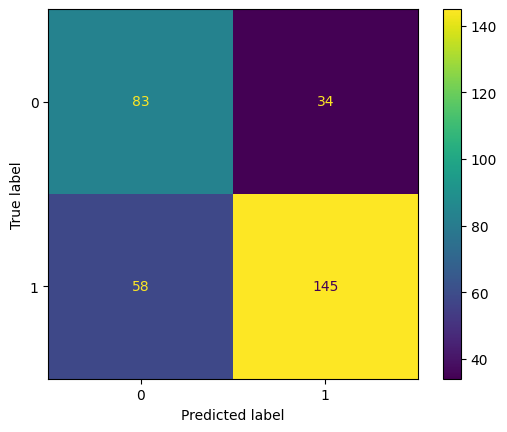

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(all_labels,all_preds)
plt.show()

In [32]:
from sklearn.metrics import roc_auc_score
ras = roc_auc_score(all_labels,all_preds)

In [34]:
ras

np.float64(0.7118437118437118)

In [ ]:
from sklearn.metrics import roc_curve,auc,precision_recall_curve,average_precision_score


In [ ]:
from sklearn.metrics import accuracy_score

all_probs = list()
all_labels = list()

model.eval()

with torch.inference_mode():
     for batch_idx , (image , label) in enumerate(test_loader):
         image = image.to(device)
         label = label.to(device)
         outputs = model(image)
         preds = outputs.softmax(dim=1)
         all_preds.extend(preds.cpu().numpy())
         all_labels.extend(label.cpu().numpy())



In [ ]:
fpr,tpr,thresholds = roc_curve(all_labels,all_preds)
roc_auc = auc(fpr,tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()